# In-Class Exercise on Spam Filtering  
In this exercise, we will use powerful tools such as pandas and sklearn to distinguish between spam and regular emails based on the information contained in the emails themselves.


## Download Data  
The data is downloaded using gdown into the same folder as the current file. After downloading, we unzip the received data.

In [1]:
#### YOUR CODE HERE ####
import os
import gdown
import zipfile


url = "https://drive.google.com/uc?id=1bTJKchSInd3IgLs41b1_-Gd-T36a_pal"
zip_file_path = "spam_ham_dataset.zip"
gdown.download(url, zip_file_path)


with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(".")

if os.path.exists(zip_file_path):
  os.remove(zip_file_path)

#### END YOUR CODE #####

Downloading...
From: https://drive.google.com/uc?id=1bTJKchSInd3IgLs41b1_-Gd-T36a_pal
To: /content/spam_ham_dataset.zip
100%|██████████| 1.95M/1.95M [00:00<00:00, 54.0MB/s]


## Using Pandas for Storage  
Pandas is a commonly used library for storing data utilized in machine learning processes, offering functions suitable for large datasets and high performance. We read the data from the unzipped file into a `DataFrame`.


In [2]:
#### YOUR CODE HERE ####
import pandas as pd

file_path = "spam_ham_dataset.csv"
df = pd.read_csv(file_path)
#### END YOUR CODE #####

Visualizing Data with 5 Examples

In [3]:
#### YOUR CODE HERE ####
df.head( n = 5)
#### END YOUR CODE #####

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [4]:
df.value_counts('label')

,count
label,
ham,3672
spam,1499


## Data Preprocessing  
As we can see, the current data contains Windows newline characters `\r\n`, which may cause confusion. To simplify, we replace them with spaces. You can also apply additional Pandas methods (e.g., removing the "Subject:" prefix, extracting the first line, etc.).


In [5]:
df['text'][0]

"Subject: enron methanol ; meter # : 988291\r\nthis is a follow up to the note i gave you on monday , 4 / 3 / 00 { preliminary\r\nflow data provided by daren } .\r\nplease override pop ' s daily volume { presently zero } to reflect daily\r\nactivity you can obtain from gas control .\r\nthis change is needed asap for economics purposes ."

In [6]:
#### YOUR CODE HERE ####

df[['Subject', 'Content']] = df['text'].str.split('\r\n', n=1, expand=True)

df['Subject'] = df['Subject'].str.replace('Subject: ', '', regex=False)

df['Content'] = df['Content'].str.replace('\r\n', ' ', regex = False)

df = df.drop('text', axis = 1)

#### END YOUR CODE #####

In [7]:
df['Subject'][0]

'enron methanol ; meter # : 988291'

In [8]:
df['Content'][0]

"this is a follow up to the note i gave you on monday , 4 / 3 / 00 { preliminary flow data provided by daren } . please override pop ' s daily volume { presently zero } to reflect daily activity you can obtain from gas control . this change is needed asap for economics purposes ."

## Building Model  
First, we perform vectorization of the input data using `CountVectorizer`, aiming to convert text data into numerical representations. `CountVectorizer` creates a vocabulary of words appearing in the dataset and generates a corresponding vector for each sample, representing the word frequencies within that sample.


In [9]:
from sklearn.feature_extraction.text import CountVectorizer
#### YOUR CODE HERE ####
df['full_text'] = df['Subject'] + ' ' + df['Content']
vectorizer = CountVectorizer()
doc_term_matrix = vectorizer.fit_transform(df['full_text'])

print(doc_term_matrix.shape) # Scipy for sparse matrix
#### END YOUR CODE #####

(5171, 50447)


Next, we apply the TF-IDF algorithm to the obtained vector. The output remains a sparse matrix but is now adjusted for the rarity of each word.


In [10]:
from sklearn.feature_extraction.text import TfidfTransformer
#### YOUR CODE HERE ####

transformer = TfidfTransformer()
tfidf_matrix = transformer.fit_transform(doc_term_matrix)

print(tfidf_matrix.shape)

#### END YOUR CODE #####

(5171, 50447)


We can generate n-gram data using the `ngram_range` argument in `CountVectorizer`, allowing the program to capture commonly occurring n-word phrases in the dataset.  

Additionally, `CountVectorizer` and `TfidfTransformer` have a combined wrapper that integrates both processes into one while accepting their shared arguments: `TfidfVectorizer`.


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
#### YOUR CODE HERE ####

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['full_text'])

print(tfidf_matrix.shape)
#### END YOUR CODE #####

(5171, 50447)


After completing the vectorization steps, we proceed to split the data into training and testing sets to evaluate the model's performance.








In [12]:
from sklearn.model_selection import train_test_split
#### YOUR CODE HERE ####

X_train, X_test, y_train, y_test = train_test_split(df['full_text'], df['label_num'], test_size = 0.3, random_state=42, stratify=df['label_num'])
#### END YOUR CODE #####

Once we have the vectorized data, we use a Bayesian model to compute the results, such as `GaussianNB`. Other machine learning models can also be applied here (e.g., `LogisticRegression`, `SVM`).  

**Note:** The `todense()` function is used to convert a sparse matrix to a dense matrix, which may cause `MemoryError` for large datasets. Consider using models that support training with sparse matrices or implementing your own solution here.


In [13]:
from sklearn.naive_bayes import GaussianNB
#### YOUR CODE HERE ####


def train_model(X_train_transformed, X_test_transformed):
  gnb = GaussianNB()
  gnb.fit(X_train_transformed, y_train)
  y_pred = gnb.predict(X_test_transformed)

  return y_pred

#### END YOUR CODE #####

In [14]:
X_tfidf_train_dense = tfidf_vectorizer.fit_transform(X_train).toarray()
X_tfidf_test_dense = tfidf_vectorizer.transform(X_test).toarray()
y_tfidf_pred = train_model(X_tfidf_train_dense, X_tfidf_test_dense)

## Metrics and Visualization  
To evaluate the model's performance, we can compute the F1 score or accuracy. In this case, we use the F1 score since the class distribution in the dataset is imbalanced (with 25% spam).  

Additionally, we can plot the ROC-AUC curve to visualize different cutoff points for the model.


In [15]:
import numpy as np
from sklearn.metrics import confusion_matrix

def eval(y_pred, method_name):

  print(f"----------------- {method_name} -----------------")

  cf_matrix = confusion_matrix(y_test, y_pred)
  print(cf_matrix)

  recall_ham =  cf_matrix[0][0] / np.sum(cf_matrix, axis = 1)[0]
  precision_ham = cf_matrix[0][0] / np.sum(cf_matrix, axis = 0)[0]
  f1_score_ham = 2 * recall_ham * precision_ham / (recall_ham + precision_ham)
  ham = [recall_ham, precision_ham, f1_score_ham]


  recall_spam =  cf_matrix[1][1] / np.sum(cf_matrix, axis = 1)[1]
  precision_spam = cf_matrix[1][1] / np.sum(cf_matrix, axis = 0)[1]
  f1_score_spam = 2 * recall_spam * precision_spam / (recall_spam + precision_spam)
  spam = [recall_spam, precision_spam, f1_score_spam]

  print("----- Ham -----")
  print(f"Recall: {recall_ham:.2%}")
  print(f"Precision: {precision_ham:.2%}")
  print(f"F1 score: {f1_score_ham:.2%}")

  print("----- Spam -----")
  print(f"Recall: {recall_spam:.2%}")
  print(f"Precision: {precision_spam:.2%}")
  print(f"F1 score: {f1_score_spam:.2%}")

  return ham, spam

In [16]:
tfidf_ham, tfidf_spam = eval(y_tfidf_pred, "TF-IDF")

----------------- TF-IDF -----------------
[[1053   49]
 [  39  411]]
----- Ham -----
Recall: 95.55%
Precision: 96.43%
F1 score: 95.99%
----- Spam -----
Recall: 91.33%
Precision: 89.35%
F1 score: 90.33%


## Alternative: Co-occurrence and TruncatedSVD  

In language, semantically related words (e.g., *doctor* and *patient*) often appear in the same context. Based on this idea, we can construct a co-occurrence matrix that captures word occurrences within sentences. This allows us to represent words in a shared vector space rather than relying on simple frequency counts.  

A co-occurrence matrix with a window spanning the entire sentence can be built using the existing `CountVectorizer` data or manually constructed.


In [17]:
from sklearn.decomposition import TruncatedSVD

full_tfidf_matrix = tfidf_vectorizer.transform(df['full_text'])
co_occurence_full = full_tfidf_matrix.T * full_tfidf_matrix

num_dims = 150
truncated_svd_word = TruncatedSVD(n_components=num_dims, random_state=42)
word_embeddings_cooc = truncated_svd_word.fit_transform(co_occurence_full)

print(f"The full TF-IDF matrix: {full_tfidf_matrix.shape}")  # (Num_doc_full, num_vocab_full)
print(f"The global co-occurrence matrix: {co_occurence_full.shape}") # (num_vocab_full, num_vocab_full)
print(f"The global word embeddings after TruncatedSVD: {word_embeddings_cooc.shape}") # (num_vocab_full, num_dims)

#### END YOUR CODE #####

The full TF-IDF matrix: (5171, 41326)
The global co-occurrence matrix: (41326, 41326)
The global word embeddings after TruncatedSVD: (41326, 150)


Each word in the text corresponds to an embedding in svd_matrix. I will take all the embeddings from words in each text, then averages them to get the embeddings for each text.

In [18]:
import numpy as np

# Function to get document embeddings by averaging word embeddings
def get_document_embeddings(documents, tfidf_vectorizer_instance, word_embeddings_matrix):
    doc_embeddings = []

    vocabulary = tfidf_vectorizer_instance.vocabulary_
    oov_embedding = np.zeros(word_embeddings_matrix.shape[1]) # Default for OOV: 0
    analyzer = tfidf_vectorizer_instance.build_analyzer() # To get consistence text processing

    for doc in documents:
        processed_words = analyzer(doc)
        word_vecs = []
        for word in processed_words:
            idx = vocabulary.get(word)

            if idx is not None:
                word_vecs.append(word_embeddings_matrix[idx])
        if word_vecs:
            doc_embeddings.append(np.mean(word_vecs, axis=0))
        else:
            doc_embeddings.append(oov_embedding) # 0 vector
    return np.array(doc_embeddings)


X_svd_train = get_document_embeddings(X_train, tfidf_vectorizer, word_embeddings_cooc)
X_svd_test = get_document_embeddings(X_test, tfidf_vectorizer, word_embeddings_cooc)

print(f"Shape of X_svd_train: {X_svd_train.shape}")
print(f"Shape of X_svd_test: {X_svd_test.shape}")

Shape of X_svd_train: (3619, 150)
Shape of X_svd_test: (1552, 150)


In [19]:
y_coocurence_svd_pred = train_model(X_svd_train, X_svd_test)
coocurence_svd_ham, coocurence_svd_spam = eval(y_coocurence_svd_pred, "Co-occurence and Truncated SVD")

----------------- Co-occurence and Truncated SVD -----------------
[[814 288]
 [ 23 427]]
----- Ham -----
Recall: 73.87%
Precision: 97.25%
F1 score: 83.96%
----- Spam -----
Recall: 94.89%
Precision: 59.72%
F1 score: 73.30%


## Alternative: HashingVectorizer  

For large datasets with a high vocabulary size, using `CountVectorizer` for vectorized data storage can be resource-intensive. An alternative approach is to use `HashingVectorizer`. Unlike `CountVectorizer`, which assigns a unique ID to each word/ngram, `HashingVectorizer` maps multiple words to the same ID using a hashing function.  

The choice between these two methods involves a trade-off between memory usage (e.g., RAM) and model quality. Adjusting the `n_features` parameter helps balance this trade-off to ensure that model performance does not degrade significantly.


In [20]:
#### YOUR CODE HERE ####
from sklearn.feature_extraction.text import HashingVectorizer

num_features = 2 ** 10

hash_vectorizer = HashingVectorizer(n_features = num_features)
X_hash_train = hash_vectorizer.transform(X_train).toarray()

hash_vectorizer = HashingVectorizer(n_features = num_features)
X_hash_test = hash_vectorizer.transform(X_test).toarray()

print(X_hash_train.shape)

#### END YOUR CODE #####

(3619, 1024)


In [21]:
y_hash_pred = train_model(X_hash_train, X_hash_test)
hash_ham, hash_spam = eval(y_hash_pred, "Hashing Vectorizer")

----------------- Hashing Vectorizer -----------------
[[948 154]
 [ 35 415]]
----- Ham -----
Recall: 86.03%
Precision: 96.44%
F1 score: 90.94%
----- Spam -----
Recall: 92.22%
Precision: 72.93%
F1 score: 81.45%


## Comparison and Analysis of Feature Extraction Methods  

Plotting function to generate three bar charts for the 'Ham' category: one for 'Recall (Ham)', one for 'Precision (Ham)', and one for 'F1 Score (Ham)'. Each chart will compare the TF-IDF, Co-occurrence + SVD, and Hashing Vectorizer methods.

In [22]:
import matplotlib.pyplot as plt
import numpy as np

def plot_metrics(metric_name, category, tfidf_score, cooc_svd_score, hashing_score):
    methods = ['TF-IDF', 'Co-occurrence + SVD', 'Hashing Vectorizer']
    scores = [tfidf_score, cooc_svd_score, hashing_score]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(methods, scores, color=['skyblue', 'lightcoral', 'lightgreen'])
    plt.ylabel(metric_name)
    plt.title(f'{metric_name} for {category}')
    plt.ylim(0.0, 1.0)
    plt.yticks(np.arange(0, 1.1, 0.1))

    # Display scores on top of the bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, round(yval, 2), ha='center', va='bottom')

    plt.show()

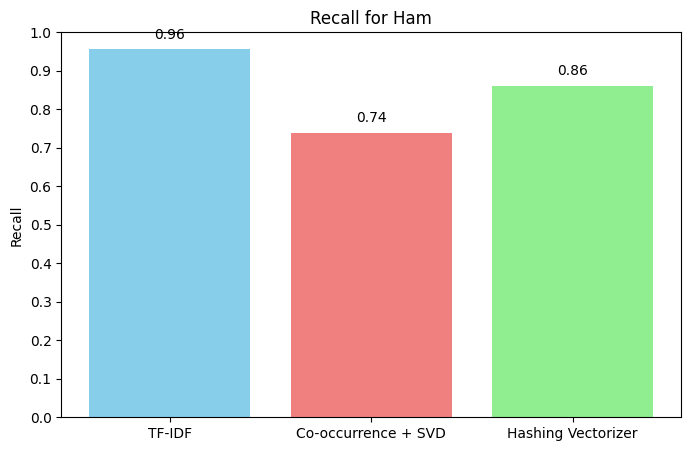

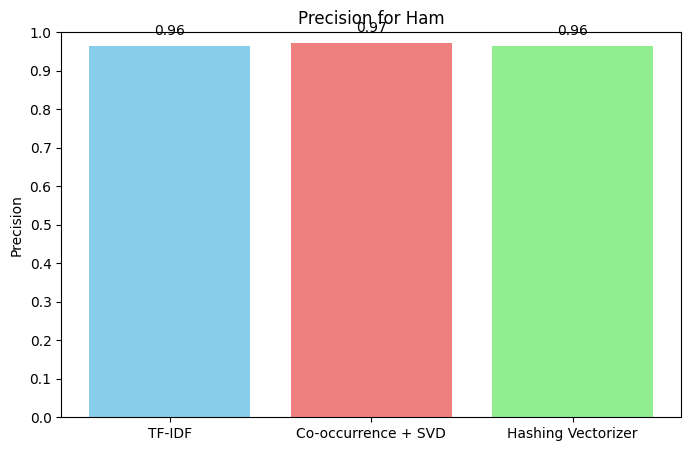

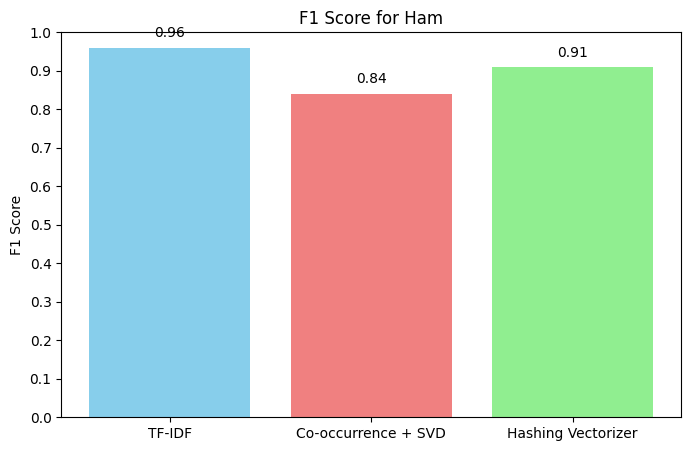

In [23]:
plot_metrics('Recall', 'Ham', tfidf_ham[0], coocurence_svd_ham[0], hash_ham[0])
plot_metrics('Precision', 'Ham', tfidf_ham[1], coocurence_svd_ham[1], hash_ham[1])
plot_metrics('F1 Score', 'Ham', tfidf_ham[2], coocurence_svd_ham[2], hash_ham[2])

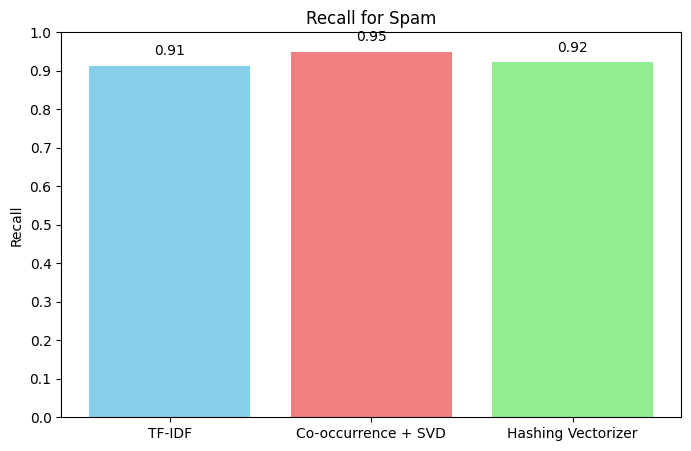

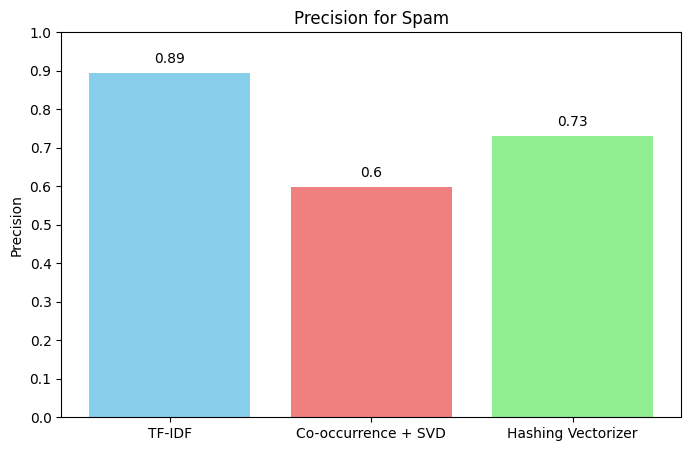

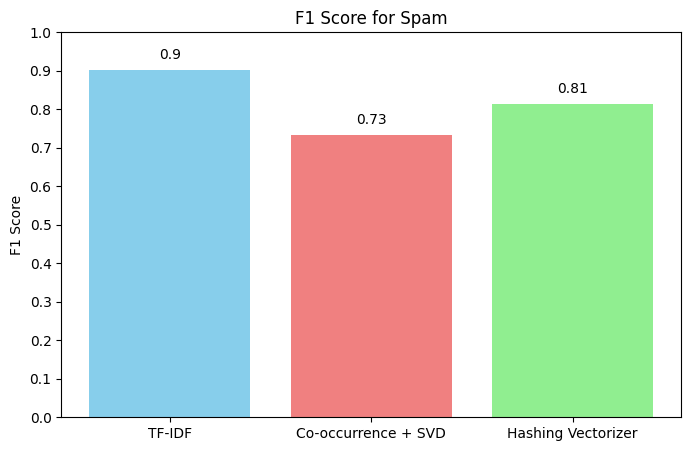

In [24]:
plot_metrics('Recall', 'Spam', tfidf_spam[0], coocurence_svd_spam[0], hash_spam[0])
plot_metrics('Precision', 'Spam', tfidf_spam[1], coocurence_svd_spam[1], hash_spam[1])
plot_metrics('F1 Score', 'Spam', tfidf_spam[2], coocurence_svd_spam[2], hash_spam[2])

## Evaluation

Spam filtering really consider the case where the email is actually ham. Because, if the person missed an important email, that could be a nightmare for them. So, we should weight much on the recall from ham, and the precision from spam. As we can see, TF-IDF outperform on all metrics. The Hassing vectorizer perform quite good compared to TF-IDF features. While the Co-occurence matrix combining with the compression from SVD has pretty low score on important metrics such as Recall for ham, and precision for spam.